In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [5]:
print(path)

/kaggle/input/creditcardfraud


In [6]:
import os

os.listdir(path)

['creditcard.csv']

In [7]:
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [11]:
print("Rows and Columns:", df.shape)

Rows and Columns: (284807, 31)


In [12]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [13]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [14]:
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]

print("Fraud Transactions :", fraud)
print("Normal Transactions:", normal)

print("Fraud Percentage:", round((fraud/len(df))*100,4),"%")

Fraud Transactions : 492
Normal Transactions: 284315
Fraud Percentage: 0.1727 %


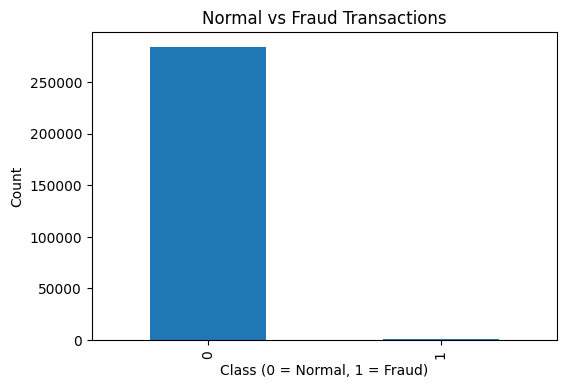

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar')

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

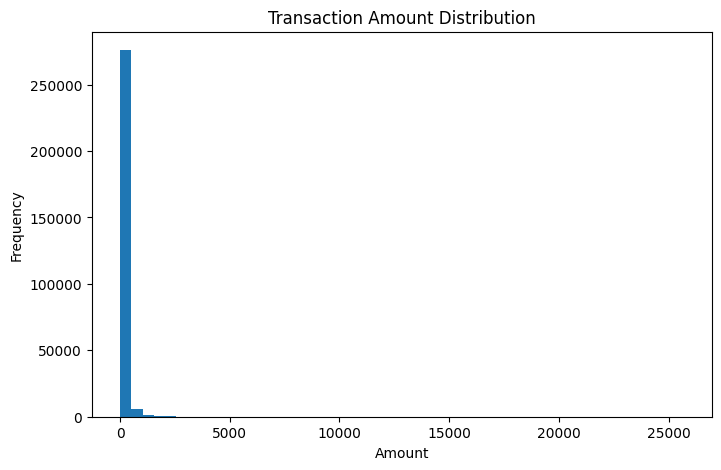

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [17]:
# Separating input features (X) and target variable (y)

X = df.drop("Class", axis=1)
y = df["Class"]

# Display the shape of features and target
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


In [18]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
# Display the shape of training and testing datasets

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (227845, 30)
Testing Features  : (56962, 30)
Training Labels   : (227845,)
Testing Labels    : (56962,)


In [20]:
# Display class distribution in training data

print("Training Data Class Distribution")
print(y_train.value_counts())

print("\nTesting Data Class Distribution")
print(y_test.value_counts())

Training Data Class Distribution
Class
0    227451
1       394
Name: count, dtype: int64

Testing Data Class Distribution
Class
0    56864
1       98
Name: count, dtype: int64


In [21]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully.")

✅ Logistic Regression model trained successfully.


In [22]:
# Predict class labels on testing data

y_pred_lr = lr_model.predict(X_test)

# Display first 10 predictions

print("Predicted Labels:")
print(y_pred_lr[:10])

Predicted Labels:
[0 0 0 0 0 0 0 0 0 0]


In [23]:
# Import evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

# Print results

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.999
Precision: 0.6923
Recall   : 0.7347
F1 Score : 0.7129


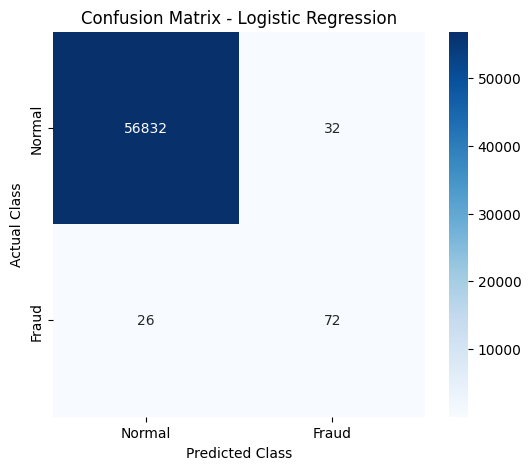

In [24]:
# Import confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Fraud"],
    yticklabels=["Normal","Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [25]:
# Import classification report

from sklearn.metrics import classification_report

# Display classification report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.73      0.71        98

    accuracy                           1.00     56962
   macro avg       0.85      0.87      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
# Import ROC-AUC functions

from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities

y_prob_lr = lr_model.predict_proba(X_test)[:,1]

# Calculate ROC-AUC score

auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", round(auc,4))

ROC-AUC Score: 0.9357


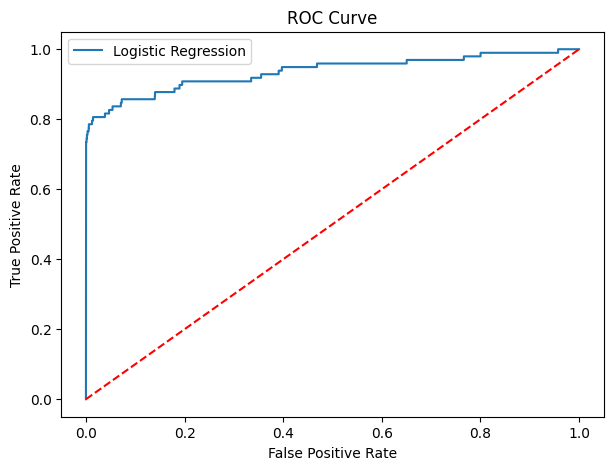

In [27]:
# Calculate ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Plot ROC Curve

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [28]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model

dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model

dt_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully!")

✅ Decision Tree model trained successfully!


In [29]:
# Predict the class labels for the testing dataset

y_pred_dt = dt_model.predict(X_test)

# Display first 10 predictions

print("First 10 Predictions:")
print(y_pred_dt[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [30]:
# Calculate evaluation metrics

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Display evaluation metrics

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")

Accuracy : 0.9991
Precision: 0.7526
Recall   : 0.7449
F1 Score : 0.7487


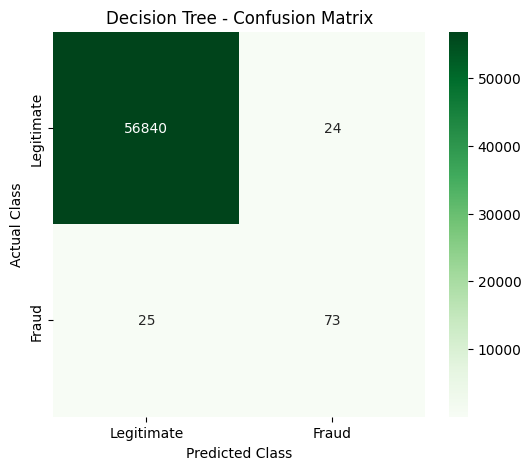

In [31]:
# Generate Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [32]:
# Display Classification Report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
# Predict probability scores for the positive class (Fraud)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC Score

auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"ROC-AUC Score: {auc_dt:.4f}")

ROC-AUC Score: 0.8722


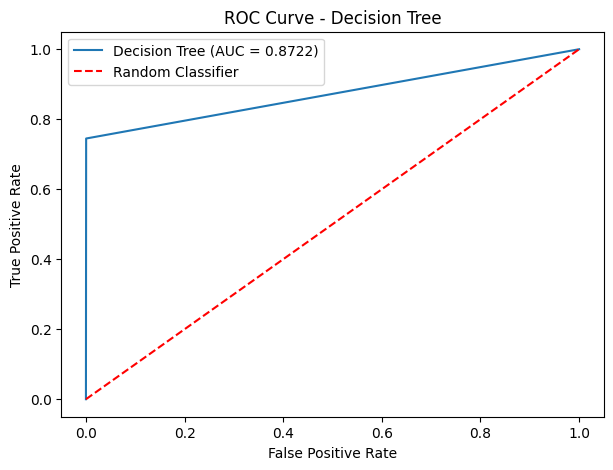

In [34]:
# Calculate False Positive Rate and True Positive Rate

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

# Plot ROC Curve

plt.figure(figsize=(7,5))

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.4f})")

plt.plot([0,1],[0,1],'r--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.show()

In [35]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model

rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [36]:
# Predict class labels

y_pred_rf = rf_model.predict(X_test)

# Display first 10 predictions

print("First 10 Predictions:")
print(y_pred_rf[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [37]:
# Calculate evaluation metrics

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Display evaluation metrics

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Accuracy : 0.9996
Precision: 0.9412
Recall   : 0.8163
F1 Score : 0.8743


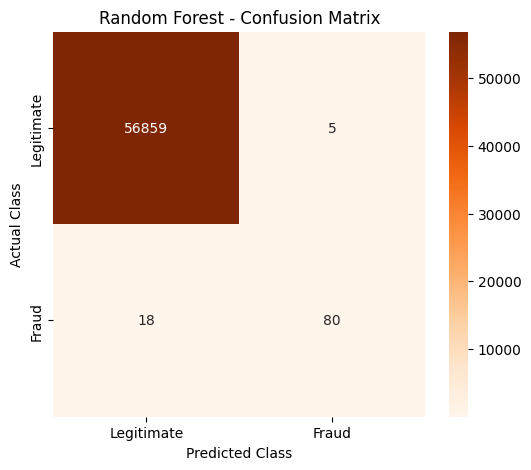

In [38]:
# Generate Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [39]:
# Display Classification Report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [40]:
# Predict probability scores

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Calculate ROC-AUC Score

auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"ROC-AUC Score: {auc_rf:.4f}")

ROC-AUC Score: 0.9630


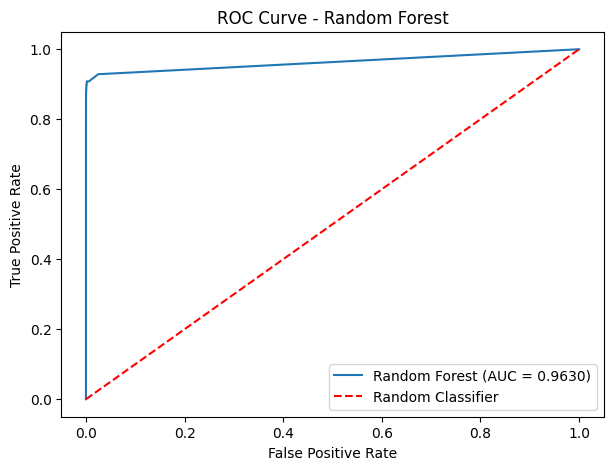

In [41]:
# Calculate ROC Curve

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

# Plot ROC Curve

plt.figure(figsize=(7,5))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")

plt.plot([0,1],[0,1],'r--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

In [42]:
# Import pandas

import pandas as pd

# Create comparison table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],

    "F1 Score": [
        f1,
        f1_dt,
        f1_rf
    ],

    "ROC-AUC": [
        auc,
        auc_dt,
        auc_rf
    ]
})

# Round values

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9990,0.6923,0.7347,0.7129,0.9357
1,Decision Tree,0.9991,0.7526,0.7449,0.7487,0.8722
2,Random Forest,0.9996,0.9412,0.8163,0.8743,0.9630


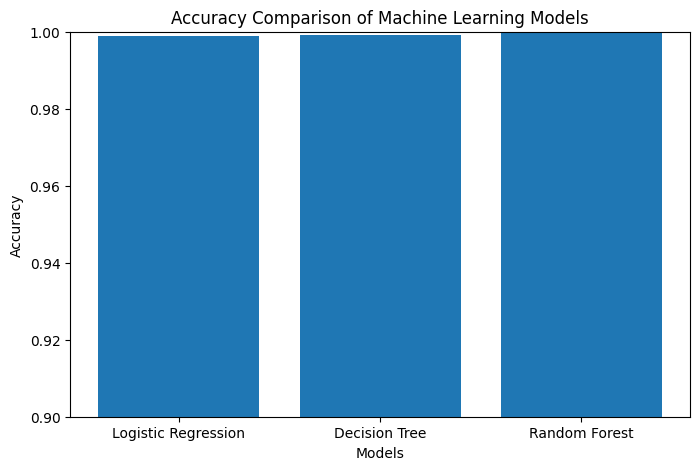

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

plt.show()

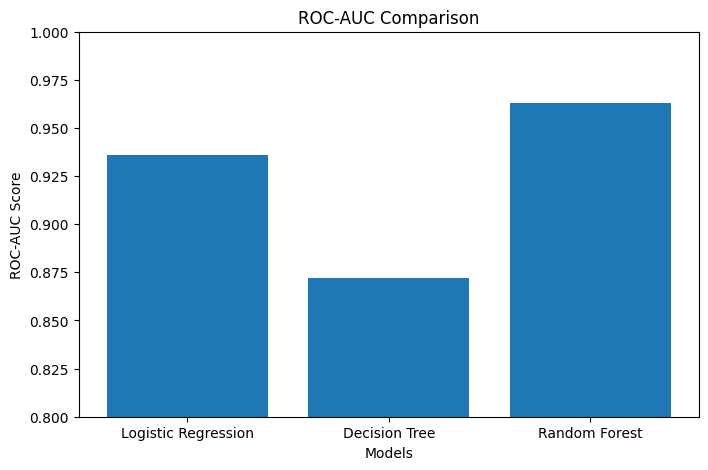

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")

plt.xlabel("Models")

plt.ylabel("ROC-AUC Score")

plt.ylim(0.80,1.00)

plt.show()

In [45]:
# Display comparison table sorted by ROC-AUC

comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.9996,0.9412,0.8163,0.8743,0.9630
0,Logistic Regression,0.9990,0.6923,0.7347,0.7129,0.9357
1,Decision Tree,0.9991,0.7526,0.7449,0.7487,0.8722


In [46]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features in descending order

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 10 Features

feature_importance.head(10)

,Feature,Importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


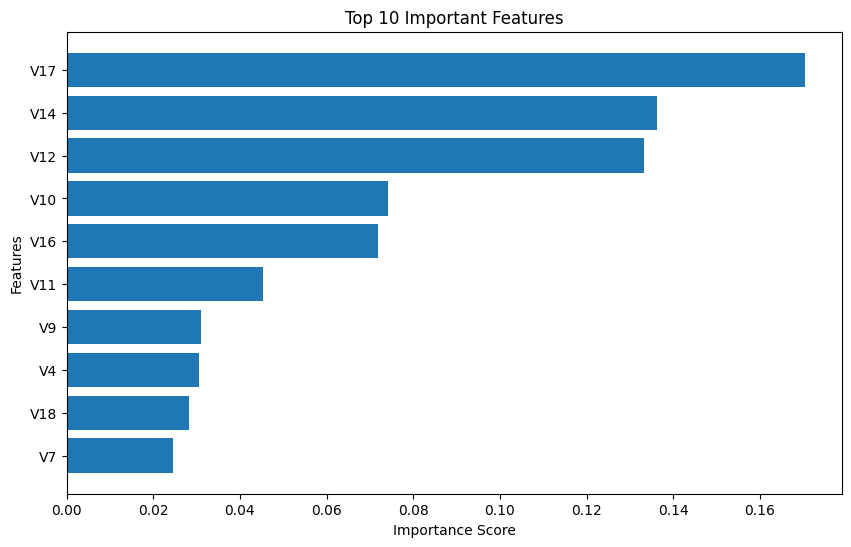

In [47]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [48]:
# Select a sample transaction from the test dataset

sample_transaction = X_test.iloc[0]

# Convert into DataFrame

sample_df = pd.DataFrame([sample_transaction])

# Predict

prediction = rf_model.predict(sample_df)

# Actual class

actual = y_test.iloc[0]

print("Actual Class :", "Fraud" if actual == 1 else "Legitimate")
print("Predicted    :", "Fraud" if prediction[0] == 1 else "Legitimate")

Actual Class : Legitimate
Predicted    : Legitimate


In [49]:
def predict_transaction(transaction):

    prediction = rf_model.predict(transaction)

    if prediction[0] == 1:
        print("🚨 Fraudulent Transaction Detected!")
    else:
        print("✅ Legitimate Transaction")

In [50]:
# Select another sample transaction

sample = X_test.iloc[[10]]

predict_transaction(sample)

✅ Legitimate Transaction
